In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/divyjain28/superstore-sales/sample_-_superstore.csv
/kaggle/input/datasets/divyjain28/superstore-sales/sample_-_superstore.xls


# 🛒 Superstore Sales Data Analysis

## 📊 Project Overview

This project analyzes a retail sales dataset using Python, Pandas, Matplotlib, and Seaborn.

The analysis focuses on:
- Sales performance
- Profit analysis
- Customer and product insights
- Regional sales trends
- Discount impact on profitability
- Data visualization

---

## 🎯 Project Objective

The main objective of this project is to explore business performance and extract valuable insights from sales data.

This project demonstrates:
- Exploratory Data Analysis (EDA)
- Business Intelligence
- Data Visualization
- Statistical Analysis
- Storytelling with Data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

## 📂 Load Dataset

In this section, we load the dataset and preview the first rows.

In [3]:
import pandas as pd
df = pd.read_csv("/kaggle/input/datasets/divyjain28/superstore-sales/sample_-_superstore.csv")
df.head()



,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,01/03/2023,01/07/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,01/05/2023,01/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


## 🔍 Exploratory Data Analysis (EDA)

We explore the dataset structure, data types, missing values, and statistical information.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales           10194 non-null 

In [5]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [6]:
df.describe()



,Row ID,Sales,Quantity,Discount,Profit
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,228.225854,3.791838,0.155385,28.673417
std,2942.898656,619.906839,2.228317,0.206249,232.465115
min,1.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2549.250000,17.220000,2.000000,0.000000,1.760800
50%,5097.500000,53.910000,3.000000,0.200000,8.690000
75%,7645.750000,209.500000,5.000000,0.200000,29.297925
max,10194.000000,22638.480000,14.000000,0.800000,8399.976000


## 🧾 Dataset Description

The dataset contains:
- Order information
- Customer details
- Product categories
- Geographic data
- Sales and profit metrics

Key columns include:
- Sales
- Profit
- Discount
- Quantity
- Category
- Region

## 💰 Profit by Category Analysis

This analysis shows how different product categories contribute to total profit.

In [7]:
category_profit = df.groupby('Category')['Profit'].sum()

category_profit

Category
Furniture           19729.9956
Office Supplies    126023.4434
Technology         146543.3756
Name: Profit, dtype: float64

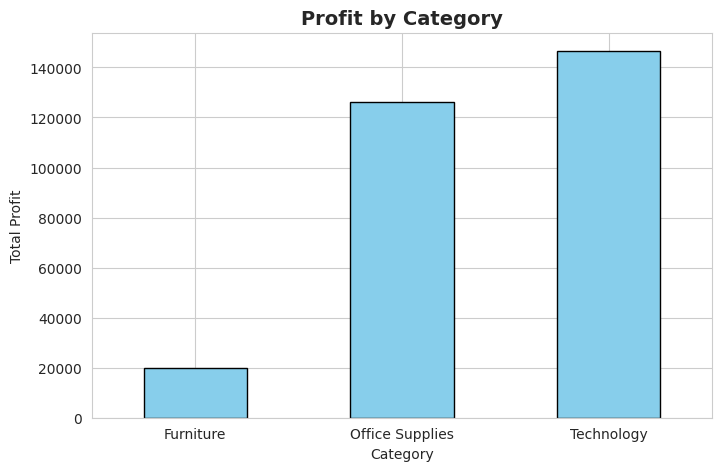

In [8]:
plt.figure(figsize=(8,5))

category_profit.plot(
    kind='bar',
    color='skyblue',
    edgecolor='black'
)

plt.title('Profit by Category', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Total Profit')

plt.xticks(rotation=0)

plt.show()

### 📌 Insight

Technology generated the highest profit among all categories.

Furniture produced significantly lower profits, which may indicate higher operational costs or lower profit margins.

## 🌍 Top Sales Cities

This section identifies the cities with the highest sales performance.

In [9]:
top_cities = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10)

top_cities

City
New York City    256368.1610
Los Angeles      175851.3410
Seattle          119540.7420
San Francisco    112669.0920
Philadelphia     109077.0130
Houston           64504.7604
Chicago           48539.5410
San Diego         47521.0290
Jacksonville      44713.1830
Springfield       43054.3420
Name: Sales, dtype: float64

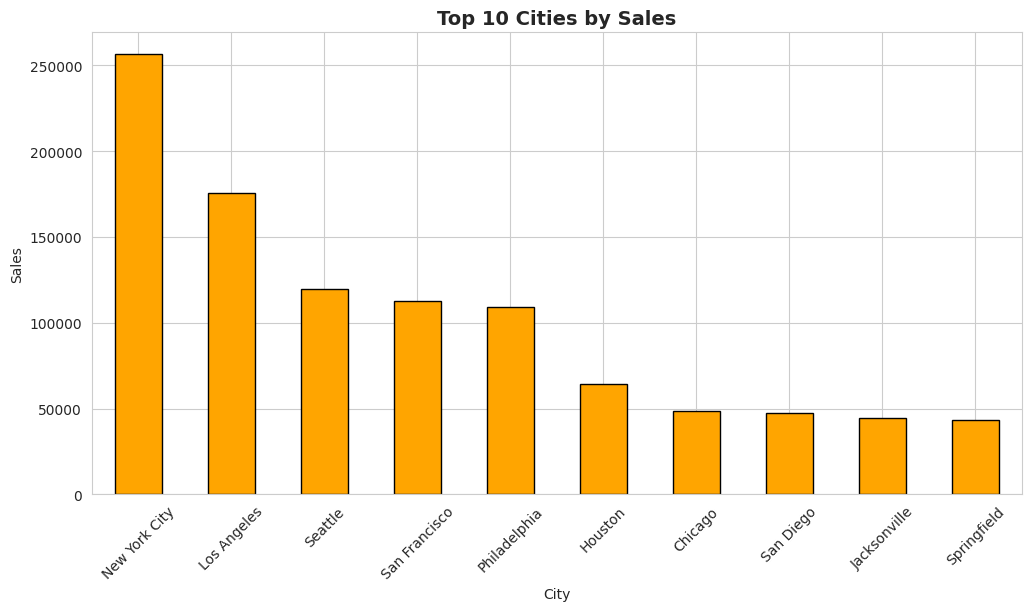

In [10]:
plt.figure(figsize=(12,6))

top_cities.plot(
    kind='bar',
    color='orange',
    edgecolor='black'
)

plt.title('Top 10 Cities by Sales', fontsize=14, fontweight='bold')
plt.xlabel('City')
plt.ylabel('Sales')

plt.xticks(rotation=45)

plt.show()

### 📌 Insight

New York City generated the highest sales revenue, followed by Los Angeles and Seattle.

Major metropolitan areas appear to drive the majority of sales performance.

## 📉 Discount vs Profit Relationship

This analysis explores the relationship between discount rates and profitability.

In [11]:
df[['Discount', 'Profit']].corr()

,Discount,Profit
Discount,1.000000,-0.218882
Profit,-0.218882,1.000000


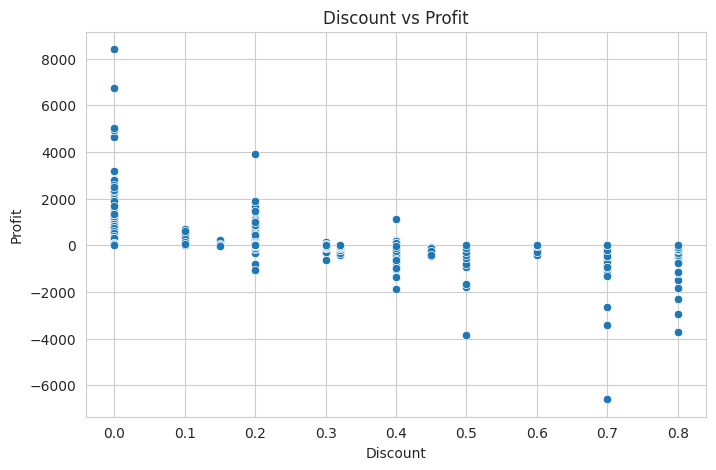

In [12]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit'
)

plt.title('Discount vs Profit')

plt.show()

### 📌 Insight

There is a negative relationship between discounts and profits.

Higher discounts tend to reduce profitability.

## 🏆 Most Profitable Products

This section identifies the products generating the highest profits.

In [13]:
top_products = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)

top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64

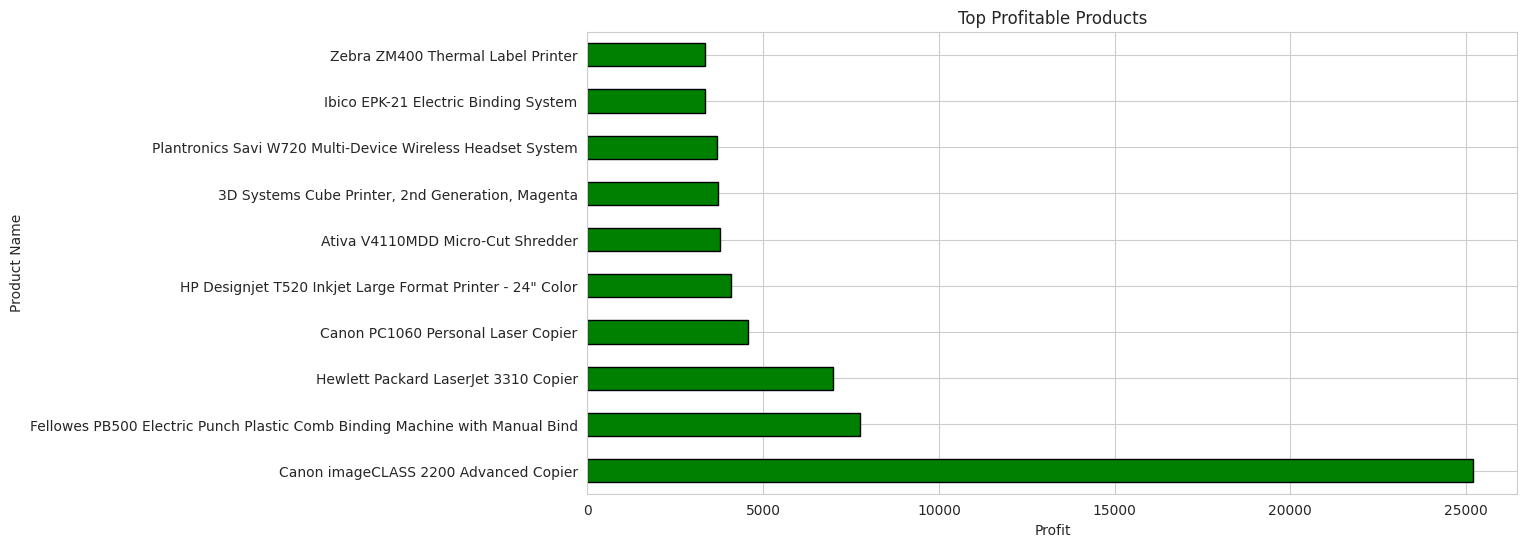

In [14]:
plt.figure(figsize=(12,6))

top_products.plot(
    kind='barh',
    color='green',
    edgecolor='black'
)

plt.title('Top Profitable Products')

plt.xlabel('Profit')

plt.show()

### 📌 Insight

Technology-related products generated exceptionally high profits.

Canon and HP products showed strong profitability performance.

## 📅 Monthly Sales Analysis

This analysis examines sales trends across different months.

In [15]:
monthly_sales = df.groupby(
    df['Order Date'].dt.month 
)['Sales'].sum()
print(monthly_sales)

AttributeError: Can only use .dt accessor with datetimelike values

In [ ]:
plt.figure(figsize=(10,5))

monthly_sales.plot(
    kind='line',
    marker='o'
)

plt.title('Monthly Sales Trend')

plt.xlabel('Month')
plt.ylabel('Sales')

plt.grid(True)

plt.show()

# ✅ Final Conclusion

Key findings from this analysis:

- Technology products generated the highest profits.
- Major cities such as New York and Los Angeles dominated sales performance.
- Discounts negatively impacted profitability.
- Sales peaked during November and December, indicating strong seasonal demand.

This project demonstrates practical skills in:
- Data Analysis
- Data Visualization
- Exploratory Data Analysis (EDA)
- Business Intelligence
- Storytelling with Data